# Primer intento:

El primer enfoque usa la definicion recursiva de Fibonacci con cache para evitar recalculos completos.

In [1]:
from functools import lru_cache


def primer_intento():
    @lru_cache(maxsize=None)
    def termino_fibonacci(n):
        if n < 2:
            return n
        return termino_fibonacci(n - 1) + termino_fibonacci(n - 2)

    resultado = 0
    valor = 0
    indice = 0
    while (valor := termino_fibonacci(indice)) <= 4_000_000:
        indice += 1
        if valor % 2 == 0:
            resultado += valor

    return resultado


primer_intento()

4613732

# Optimizacion:

chatgpt recomienda prescindir de la recurrencia

In [2]:
def optimizacion():
    resultado = 0
    a, b = 0, 1

    while b <= 4_000_000:
        if b % 2 == 0:
            resultado += b
        a, b = b, a + b

    return resultado


optimizacion()

4613732

# Comparacion:

Esta celda compara ambos metodos en tiempo y memoria.


--- Primer intento ---
Resultado: 4613732
Consistente: True
Repeticiones por corrida: 1000
Tiempo promedio: 1.176739e-05 s
Tiempo mediano: 1.165288e-05 s
Tiempo minimo: 1.152452e-05 s
Memoria promedio: 2.94 KB
Memoria mediana: 2.97 KB
Memoria maxima: 3.00 KB

--- Optimizacion ---
Resultado: 4613732
Consistente: True
Repeticiones por corrida: 10000
Tiempo promedio: 1.426492e-06 s
Tiempo mediano: 1.429817e-06 s
Tiempo minimo: 1.408661e-06 s
Memoria promedio: 0.000000e+00 KB
Memoria mediana: 0.000000e+00 KB
Memoria maxima: 0.000000e+00 KB


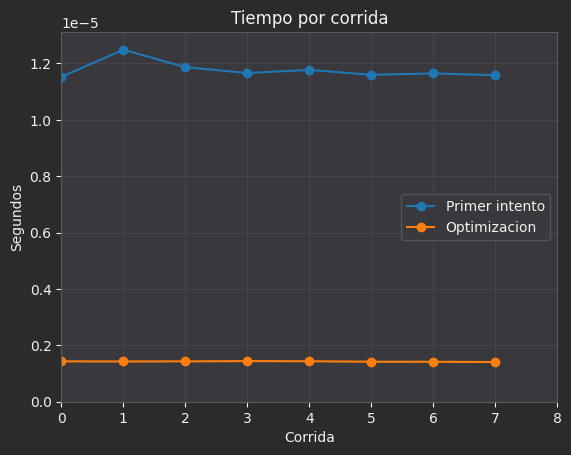

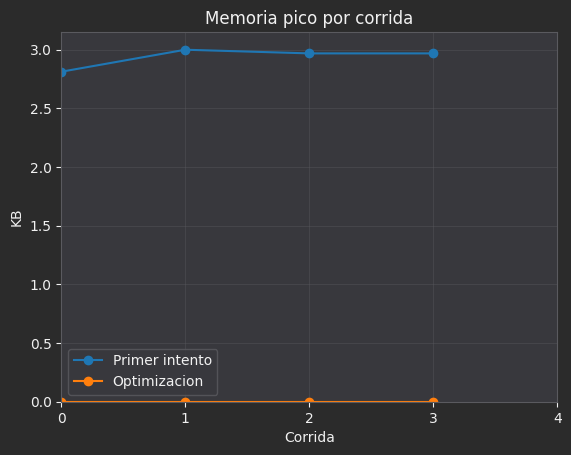

{'Primer intento': {'resultado': 4613732,
  'consistente': True,
  'tiempos': [1.1524518000000095e-05,
   1.2486759000000181e-05,
   1.1869035000000139e-05,
   1.1659344999999988e-05,
   1.1772182999999936e-05,
   1.159705699999991e-05,
   1.1646408000000052e-05,
   1.1583794999999953e-05],
  'memorias': [2.8125, 3.0, 2.96875, 2.96875],
  'repeticiones': 1000},
 'Optimizacion': {'resultado': 4613732,
  'consistente': True,
  'tiempos': [1.4318078000000067e-06,
   1.4280579999999875e-06,
   1.4315751999999905e-06,
   1.4405154000000309e-06,
   1.4353422999999754e-06,
   1.419028599999983e-06,
   1.4169450999999888e-06,
   1.4086613999999997e-06],
  'memorias': [0.0, 0.0, 0.0, 0.0],
  'repeticiones': 10000}}

In [3]:
from lib.utils import comparar_metodos

comparar_metodos(primer_intento, optimizacion)